# MobileNetV3Small 3-Class Image Classification with Keras - Center Crop

This notebook trains a 3-class classifier using `MobileNetV3Small` transfer learning with the same center-crop preprocessing, reusable data pipeline, input-size tuning, and export flow as the other 3-class notebooks.


In [17]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.10.0
GPU available: True


In [18]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16
HEAD_EPOCHS = 5
FINETUNE_EPOCHS = 5
CENTER_CROP_FRACTION = 0.75
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('saved_model/mobilenetv3small_3class_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())


Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data


In [19]:
def center_crop_array(array, crop_fraction=CENTER_CROP_FRACTION, image_size=IMAGE_SIZE):
    if not 0 < crop_fraction <= 1:
        raise ValueError('CENTER_CROP_FRACTION must be in the range (0, 1]')

    height, width = array.shape[:2]
    crop_height = max(1, int(height * crop_fraction))
    crop_width = max(1, int(width * crop_fraction))
    y0 = (height - crop_height) // 2
    x0 = (width - crop_width) // 2
    cropped = array[y0:y0 + crop_height, x0:x0 + crop_width]
    resized = tf.image.resize(cropped, image_size, method='bilinear')
    return resized.numpy().astype(np.float32)


def make_preprocess_fn(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION):
    def preprocess_fn(array):
        return preprocess_input(center_crop_array(array, crop_fraction=crop_fraction, image_size=image_size))
    return preprocess_fn


preprocess_final_input = make_preprocess_fn()


In [20]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())


,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074812_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130316_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


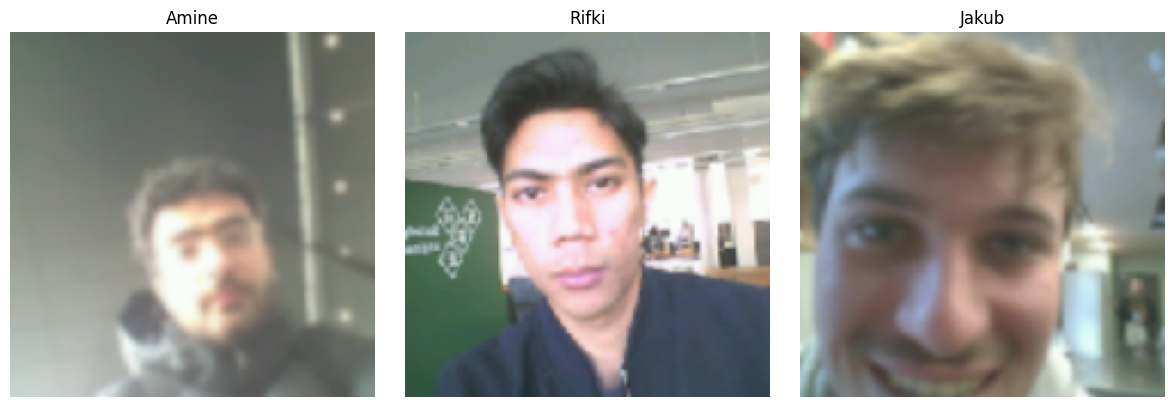

In [21]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
    image_array = keras.utils.img_to_array(image)
    cropped_image = center_crop_array(image_array).astype(np.uint8)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(cropped_image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [22]:
def make_data_generators(image_size=IMAGE_SIZE, crop_fraction=CENTER_CROP_FRACTION):
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction)

    train_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2,
        rotation_range=12,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        brightness_range=(0.9, 1.1),
        horizontal_flip=True,
    )

    test_datagen = keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_fn,
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='training',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True,
    )

    val_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        subset='validation',
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=False,
    )

    test_gen = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=image_size,
        keep_aspect_ratio=True,
        class_mode='categorical',
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


train_gen, val_gen, test_gen = make_data_generators()
print('Class indices:', train_gen.class_indices)


Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [23]:
def build_mobilenetv3small_model(config: dict, model_name: str = 'MobileNetV3Small_3Class') -> keras.Model:
    image_size = tuple(config.get('image_size', IMAGE_SIZE))
    alpha = float(config['alpha'])
    dropout = float(config['dropout'])
    dense_units = int(config['dense_units'])
    l2_strength = float(config['l2'])
    learning_rate = float(config['learning_rate'])
    regularizer = keras.regularizers.l2(l2_strength) if l2_strength else None

    base_model = MobileNetV3Small(
        include_top=False,
        weights='imagenet',
        input_shape=image_size + (3,),
        alpha=alpha,
    )
    base_model.trainable = False

    inputs = keras.Input(shape=image_size + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(
        dense_units,
        activation='relu',
        kernel_regularizer=regularizer,
    )(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(
        len(CLASS_NAMES),
        activation='softmax',
        kernel_regularizer=regularizer,
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def unfreeze_last_base_layers(model: keras.Model, trainable_layers: int):
    base_model = model.layers[1]
    base_model.trainable = True

    for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False

    return base_model


## Hyperparameter Tuning

Run this section before final training to compare MobileNetV3Small classifier-head settings, width multiplier, and input size on the same center-crop preprocessing pipeline.


In [24]:
TUNING_EPOCHS = 5

TUNING_CONFIGS = [
    {'image_size': (128, 128), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (160, 160), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.3, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 1e-3, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (160, 160), 'crop_fraction': 0.70, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 1e-4, 'learning_rate': 5e-4, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-5},
    {'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 1e-4, 'learning_rate': 5e-4, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-5},
]


tuning_results = []
for run_id, config in enumerate(TUNING_CONFIGS, start=1):
    print(f'\nTuning run {run_id}/{len(TUNING_CONFIGS)}: {config}')
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    tuning_train_gen, tuning_val_gen, _ = make_data_generators(
        image_size=tuple(config['image_size']),
        crop_fraction=float(config['crop_fraction']),
    )
    tuning_model = build_mobilenetv3small_model(config, model_name=f'MobileNetV3Small_3Class_Tuning_{run_id}')
    print('Model summary before training:')
    tuning_model.summary()
    tuning_history = tuning_model.fit(
        tuning_train_gen,
        validation_data=tuning_val_gen,
        epochs=TUNING_EPOCHS,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ],
        verbose=1,
    )

    best_val_accuracy = max(tuning_history.history['val_accuracy'])
    best_val_loss = min(tuning_history.history['val_loss'])
    tuning_results.append({
        'run_id': run_id,
        **config,
        'image_size': f'{config["image_size"][0]}x{config["image_size"][1]}',
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'epochs_run': len(tuning_history.history['loss']),
    })


tuning_df = pd.DataFrame(tuning_results).sort_values(
    ['best_val_accuracy', 'best_val_loss'],
    ascending=[False, True],
).reset_index(drop=True)

display(tuning_df)
best_config = tuning_df.iloc[0].to_dict()
best_config['image_size'] = tuple(int(part) for part in best_config['image_size'].split('x'))
print('Best config:')
print(best_config)



Tuning run 1/5: {'image_size': (128, 128), 'crop_fraction': 0.75, 'alpha': 0.75, 'dropout': 0.2, 'dense_units': 128, 'l2': 0.0, 'learning_rate': 0.001, 'fine_tune_layers': 20, 'fine_tune_learning_rate': 1e-05}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model summary before training:
Model: "MobileNetV3Small_3Class_Tuning_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 MobilenetV3small (Functiona  (None, 4, 4, 432)        583160    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 432)              0         
 lobalA

,run_id,image_size,crop_fraction,alpha,dropout,dense_units,l2,learning_rate,fine_tune_layers,fine_tune_learning_rate,best_val_accuracy,best_val_loss,epochs_run
0,5,192x192,0.75,1.00,0.3,160,0.0001,0.0005,30,0.00001,0.988426,0.077364,5
1,4,160x160,0.70,1.00,0.3,160,0.0001,0.0005,30,0.00001,0.986111,0.082463,5
2,2,160x160,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.983796,0.062973,5
3,3,192x192,0.75,0.75,0.3,128,0.0000,0.0010,20,0.00001,0.981481,0.072441,5
4,1,128x128,0.75,0.75,0.2,128,0.0000,0.0010,20,0.00001,0.976852,0.078464,5


Best config:
{'run_id': 5, 'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 0.0001, 'learning_rate': 0.0005, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-05, 'best_val_accuracy': 0.9884259104728699, 'best_val_loss': 0.07736416161060333, 'epochs_run': 5}


In [25]:
DEFAULT_FINAL_CONFIG = {
    'image_size': IMAGE_SIZE,
    'crop_fraction': CENTER_CROP_FRACTION,
    'alpha': 0.75,
    'dropout': 0.2,
    'dense_units': 128,
    'l2': 0.0,
    'learning_rate': 1e-3,
    'fine_tune_layers': 20,
    'fine_tune_learning_rate': 1e-5,
}

FINAL_CONFIG = dict(DEFAULT_FINAL_CONFIG)
if 'best_config' in globals():
    FINAL_CONFIG.update({
        'image_size': tuple(best_config['image_size']),
        'crop_fraction': float(best_config['crop_fraction']),
        'alpha': float(best_config['alpha']),
        'dropout': float(best_config['dropout']),
        'dense_units': int(best_config['dense_units']),
        'l2': float(best_config['l2']),
        'learning_rate': float(best_config['learning_rate']),
        'fine_tune_layers': int(best_config['fine_tune_layers']),
        'fine_tune_learning_rate': float(best_config['fine_tune_learning_rate']),
    })

print('Final training config:', FINAL_CONFIG)
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

IMAGE_SIZE = tuple(FINAL_CONFIG['image_size'])
preprocess_final_input = make_preprocess_fn(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
)
train_gen, val_gen, test_gen = make_data_generators(
    image_size=IMAGE_SIZE,
    crop_fraction=FINAL_CONFIG['crop_fraction'],
)

model = build_mobilenetv3small_model(FINAL_CONFIG)
model.summary()


Final training config: {'image_size': (192, 192), 'crop_fraction': 0.75, 'alpha': 1.0, 'dropout': 0.3, 'dense_units': 160, 'l2': 0.0001, 'learning_rate': 0.0005, 'fine_tune_layers': 30, 'fine_tune_learning_rate': 1e-05}
Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Model: "MobileNetV3Small_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 192, 192, 3)]     0         
                                                                 
 MobilenetV3small (Functiona  (None, 6, 6, 576)        939120    
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 576)              0         
 lobalAveragePooling2D)               

In [26]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)


Epoch 1/5
108/108 [==============================] - 21s 178ms/step - loss: 0.7112 - accuracy: 0.7089 - val_loss: 0.2773 - val_accuracy: 0.9352 - lr: 5.0000e-04
Epoch 2/5
108/108 [==============================] - 19s 180ms/step - loss: 0.3234 - accuracy: 0.8953 - val_loss: 0.1597 - val_accuracy: 0.9745 - lr: 5.0000e-04
Epoch 3/5
108/108 [==============================] - 19s 179ms/step - loss: 0.2345 - accuracy: 0.9271 - val_loss: 0.0966 - val_accuracy: 0.9838 - lr: 5.0000e-04
Epoch 4/5
108/108 [==============================] - 28s 264ms/step - loss: 0.1829 - accuracy: 0.9444 - val_loss: 0.1083 - val_accuracy: 0.9815 - lr: 5.0000e-04
Epoch 5/5
108/108 [==============================] - 36s 332ms/step - loss: 0.1867 - accuracy: 0.9456 - val_loss: 0.0774 - val_accuracy: 0.9884 - lr: 5.0000e-04


In [27]:
unfreeze_last_base_layers(model, trainable_layers=FINAL_CONFIG['fine_tune_layers'])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINAL_CONFIG['fine_tune_learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)


Epoch 1/5
108/108 [==============================] - 43s 360ms/step - loss: 0.1429 - accuracy: 0.9554 - val_loss: 0.0679 - val_accuracy: 0.9954 - lr: 1.0000e-05
Epoch 2/5
108/108 [==============================] - 39s 362ms/step - loss: 0.1296 - accuracy: 0.9664 - val_loss: 0.0621 - val_accuracy: 0.9931 - lr: 1.0000e-05
Epoch 3/5
108/108 [==============================] - 38s 350ms/step - loss: 0.1421 - accuracy: 0.9641 - val_loss: 0.0544 - val_accuracy: 0.9954 - lr: 1.0000e-05
Epoch 4/5
108/108 [==============================] - 33s 302ms/step - loss: 0.1111 - accuracy: 0.9751 - val_loss: 0.0595 - val_accuracy: 0.9907 - lr: 1.0000e-05
Epoch 5/5
108/108 [==============================] - 31s 287ms/step - loss: 0.1099 - accuracy: 0.9745 - val_loss: 0.0542 - val_accuracy: 0.9954 - lr: 1.0000e-05


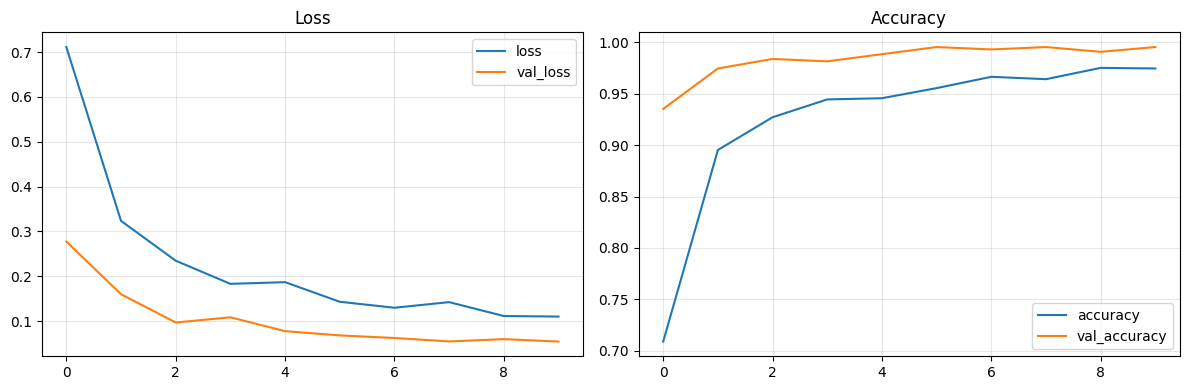

In [28]:
history = {}
for key in history_head.history:
    history[key] = history_head.history[key] + history_finetune.history[key]

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Test loss: 0.1949
Test accuracy: 0.9426

              precision    recall  f1-score   support

       Amine       0.89      0.97      0.93       180
       Rifki       0.98      1.00      0.99       180
       Jakub       0.96      0.86      0.91       180

    accuracy                           0.94       540
   macro avg       0.94      0.94      0.94       540
weighted avg       0.94      0.94      0.94       540



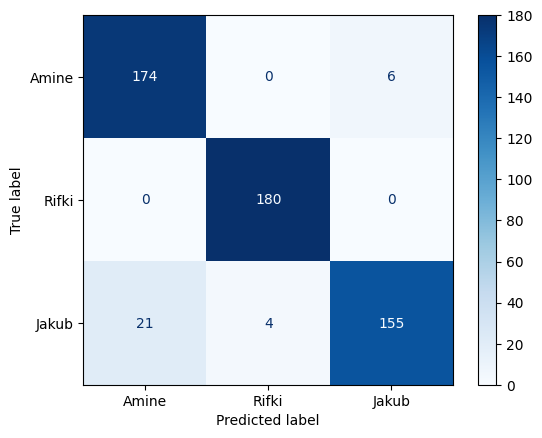

In [29]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()


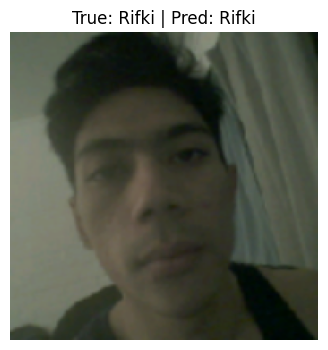

Amine: 0.0044
Rifki: 0.9912
Jakub: 0.0043

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv3small_3class_classifier.keras


In [30]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
array = keras.utils.img_to_array(image)
cropped_image = center_crop_array(array, image_size=IMAGE_SIZE).astype(np.uint8)
array = preprocess_final_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(cropped_image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print()
print('Saved model to:', MODEL_PATH.resolve())


## Export Training Subset

This section saves the preprocessed training subset used by MobileNetV3Small to `saved_model/x_train_mobilenetv3small.npy` and `saved_model/y_train_mobilenetv3small.npy` for later quantization.


In [31]:
VALIDATION_SPLIT = 0.2
X_TRAIN_PATH = MODEL_PATH.parent / 'x_train_mobilenetv3small.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / 'y_train_mobilenetv3small.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    split_index = int(len(train_df) * VALIDATION_SPLIT)
    return train_df.iloc[split_index:].reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=IMAGE_SIZE, keep_aspect_ratio=True)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_final_input(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')


Saved training subset: 1728 images
x_train shape: (1728, 192, 192, 3)
y_train shape: (1728,)
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_mobilenetv3small.npy
Saved: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\y_train_mobilenetv3small.npy


## Quantization

Export the trained MobileNetV3Small model to full INT8 TensorFlow Lite, generate C/H artifacts, and evaluate the quantized model using the same center-crop preprocessing and selected final input size.


In [37]:
import os
from utils.export_tflite import write_model_c_file, write_model_h_file

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

SCRIPT_DIR = Path.cwd()
QUANTIZED_MODEL_DIR = SCRIPT_DIR / 'quantized_model'
GEN_DIR = SCRIPT_DIR / 'gen'
KERAS_MODEL_PATH = MODEL_PATH
CALIBRATION_DATA_PATH = MODEL_PATH.parent / 'x_train_mobilenetv3small.npy'
MOBILENETV3_TFLITE_MODEL_PATH = QUANTIZED_MODEL_DIR / 'mobilenetv3small_3class_int8.tflite'
MOBILENETV3_MODEL_C_PATH = GEN_DIR / 'mobilenetv3small_model.c'
MOBILENETV3_MODEL_H_PATH = GEN_DIR / 'mobilenetv3small_model.h'
REPRESENTATIVE_DATASET_SAMPLES = 512
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print('Keras model:', KERAS_MODEL_PATH.resolve())
print('Calibration data:', CALIBRATION_DATA_PATH.resolve())
print('TFLite output:', MOBILENETV3_TFLITE_MODEL_PATH.resolve())


Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv3small_3class_classifier.keras
Calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_mobilenetv3small.npy
TFLite output: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\mobilenetv3small_3class_int8.tflite


In [38]:
def representative_indices(num_samples: int, max_samples: int = REPRESENTATIVE_DATASET_SAMPLES) -> np.ndarray:
    if num_samples <= 0:
        raise ValueError('Representative dataset requires at least one sample.')
    if num_samples <= max_samples:
        return np.arange(num_samples, dtype=np.int32)
    return np.linspace(0, num_samples - 1, num=max_samples, dtype=np.int32)


def export_model_to_tflite(model: keras.Model, x_train: np.ndarray) -> bytes:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    def representative_dataset():
        for i in representative_indices(len(x_train)):
            yield [x_train[i:i + 1].astype(np.float32)]

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


def resolve_model_img_size(model: keras.Model) -> int:
    input_shape = model.input_shape[0] if isinstance(model.input_shape, list) else model.input_shape
    if len(input_shape) != 4:
        raise ValueError(f'Expected 4D model input shape, got {input_shape}')

    height, width, channels = input_shape[1:]
    if None in (height, width, channels):
        raise ValueError(f'Model input shape must be fully defined, got {input_shape}')
    if channels != 3 or height != width:
        raise ValueError(f'Expected square RGB input, got {input_shape}')
    return int(height)


def export_artifacts(tflite_model: bytes, img_size: int):
    QUANTIZED_MODEL_DIR.mkdir(exist_ok=True)
    GEN_DIR.mkdir(exist_ok=True)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']

    defines = {
        'IMG_SIZE': img_size,
        'NUM_CLASSES': NUM_CLASSES,
        'INPUT_SCALE': f'{input_scale}f',
        'INPUT_ZERO_POINT': input_zero_point,
        'OUTPUT_SCALE': f'{output_scale}f',
        'OUTPUT_ZERO_POINT': output_zero_point,
    }
    declarations = [
        f'// Labels: {", ".join(f"{name}={idx}" for name, idx in CLASS_TO_INDEX.items())}',
    ]

    MOBILENETV3_TFLITE_MODEL_PATH.write_bytes(tflite_model)
    write_model_h_file(MOBILENETV3_MODEL_H_PATH, defines, declarations)
    write_model_c_file(MOBILENETV3_MODEL_C_PATH, tflite_model)

    print(f'Input scale:       {input_scale}')
    print(f'Input zero point:  {input_zero_point}')
    print(f'Output scale:      {output_scale}')
    print(f'Output zero point: {output_zero_point}')
    print(f'Model size:        {len(tflite_model) / 1024:.1f} KB')
    print(f'Saved: {MOBILENETV3_TFLITE_MODEL_PATH}')
    print(f'Saved: {MOBILENETV3_MODEL_C_PATH}')
    print(f'Saved: {MOBILENETV3_MODEL_H_PATH}')


def load_image_array(image_path: Path, image_size=IMAGE_SIZE) -> np.ndarray:
    crop_fraction = globals().get('QUANT_CROP_FRACTION', globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
    preprocess_fn = make_preprocess_fn(image_size=image_size, crop_fraction=crop_fraction)
    image = keras.utils.load_img(image_path, target_size=image_size, keep_aspect_ratio=True)
    array = keras.utils.img_to_array(image).astype(np.float32)
    return preprocess_fn(array)


def load_test_split(data_root: Path, image_size=IMAGE_SIZE):
    x_test, y_test = [], []
    for class_name in CLASS_NAMES:
        split_dir = data_root / class_name / 'test'
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing test split: {split_dir.resolve()}')

        for image_path in sorted(split_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.bmp'}:
                x_test.append(load_image_array(image_path, image_size=image_size))
                y_test.append(CLASS_TO_INDEX[class_name])

    if not x_test:
        raise ValueError(f'No test images found under {data_root.resolve()}')
    return np.stack(x_test).astype(np.float32), np.array(y_test, dtype=np.int32)


def load_tflite_interpreter(model_path: Path):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    return interpreter, interpreter.get_input_details()[0], interpreter.get_output_details()[0]


def resize_to_tflite_input(images: np.ndarray, input_details: dict) -> np.ndarray:
    input_shape = tuple(input_details['shape'])
    expected_shape = tuple(input_shape[1:])
    if input_shape[0] != 1 or input_shape[3] != 3:
        raise ValueError(f'Unexpected model input shape: {input_shape}')
    if images.shape[1:] == expected_shape:
        return images
    return tf.image.resize(images, input_shape[1:3], method='bilinear').numpy().astype(np.float32)


def predict_tflite(interpreter, input_details, output_details, images: np.ndarray) -> np.ndarray:
    if input_details['dtype'] != np.int8:
        raise ValueError(f'Expected int8 input tensor, got {input_details["dtype"]}')

    input_scale, input_zero_point = input_details['quantization']
    output_scale, output_zero_point = output_details['quantization']
    quantized_images = images / input_scale + input_zero_point
    quantized_images = np.clip(quantized_images, -128, 127).astype(np.int8)

    raw_predictions = np.empty((len(images), NUM_CLASSES), dtype=np.int8)
    for i, image in enumerate(quantized_images):
        interpreter.set_tensor(input_details['index'], image[None, ...])
        interpreter.invoke()
        raw_predictions[i] = interpreter.get_tensor(output_details['index'])[0]

    return (raw_predictions.astype(np.float32) - output_zero_point) * output_scale


### Export INT8 TFLite Model


In [39]:
if not KERAS_MODEL_PATH.exists():
    raise FileNotFoundError(f'Model not found: {KERAS_MODEL_PATH.resolve()}')
if not CALIBRATION_DATA_PATH.exists():
    raise FileNotFoundError(f'Calibration data not found: {CALIBRATION_DATA_PATH.resolve()}')

print(f'Loading Keras model: {KERAS_MODEL_PATH.resolve()}')
quant_model = keras.models.load_model(KERAS_MODEL_PATH)
img_size = resolve_model_img_size(quant_model)
QUANT_IMAGE_SIZE = (img_size, img_size)
QUANT_CROP_FRACTION = float(globals().get('FINAL_CONFIG', {}).get('crop_fraction', CENTER_CROP_FRACTION))
print(f'Quantization image size: {QUANT_IMAGE_SIZE}')
print(f'Quantization crop fraction: {QUANT_CROP_FRACTION}')

print(f'Loading calibration data: {CALIBRATION_DATA_PATH.resolve()}')
x_train_quant = np.load(CALIBRATION_DATA_PATH)
if x_train_quant.ndim != 4:
    raise ValueError(f'Expected x_train to be 4D, got shape {x_train_quant.shape}')
if x_train_quant.shape[1:] != (img_size, img_size, 3):
    raise ValueError(f'Calibration data shape {x_train_quant.shape} does not match model input size {img_size}')

tflite_model = export_model_to_tflite(quant_model, x_train_quant)
export_artifacts(tflite_model, img_size)


Loading Keras model: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\mobilenetv3small_3class_classifier.keras
Quantization image size: (192, 192)
Quantization crop fraction: 0.75
Loading calibration data: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\saved_model\x_train_mobilenetv3small.npy


c:\Users\Rifki\.conda\envs\TF\lib\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Input scale:       1.0
Input zero point:  -128
Output scale:      0.00390625
Output zero point: -128
Model size:        1297.2 KB
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\mobilenetv3small_3class_int8.tflite
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\mobilenetv3small_model.c
Saved: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\gen\mobilenetv3small_model.h


### Evaluate Quantized TFLite Model


In [40]:
if not MOBILENETV3_TFLITE_MODEL_PATH.exists():
    raise FileNotFoundError(f'Missing quantized model: {MOBILENETV3_TFLITE_MODEL_PATH}')
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Missing data root: {DATA_ROOT.resolve()}')

x_test_quant, y_test_quant = load_test_split(DATA_ROOT, image_size=globals().get('QUANT_IMAGE_SIZE', IMAGE_SIZE))
interpreter, input_details, output_details = load_tflite_interpreter(MOBILENETV3_TFLITE_MODEL_PATH)
x_test_quant = resize_to_tflite_input(x_test_quant, input_details)

quant_predictions = predict_tflite(interpreter, input_details, output_details, x_test_quant)
y_pred_quant = np.argmax(quant_predictions, axis=1)
quant_accuracy = np.mean(y_pred_quant == y_test_quant)
quant_cm = confusion_matrix(y_test_quant, y_pred_quant)

print(f'Model: {MOBILENETV3_TFLITE_MODEL_PATH}')
print(f'Test samples: {len(x_test_quant)}')
print(f'Quantized accuracy: {quant_accuracy:.4f}')
print()
print('Classification report:')
print(classification_report(y_test_quant, y_pred_quant, target_names=CLASS_NAMES, digits=4))
print('Confusion matrix:')
print(quant_cm)


Model: c:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\quantized_model\mobilenetv3small_3class_int8.tflite
Test samples: 540
Quantized accuracy: 0.7556

Classification report:
              precision    recall  f1-score   support

       Amine     0.6667    0.7000    0.6829       180
       Rifki     0.7907    0.7556    0.7727       180
       Jakub     0.8156    0.8111    0.8134       180

    accuracy                         0.7556       540
   macro avg     0.7577    0.7556    0.7563       540
weighted avg     0.7577    0.7556    0.7563       540

Confusion matrix:
[[126  25  29]
 [ 40 136   4]
 [ 23  11 146]]


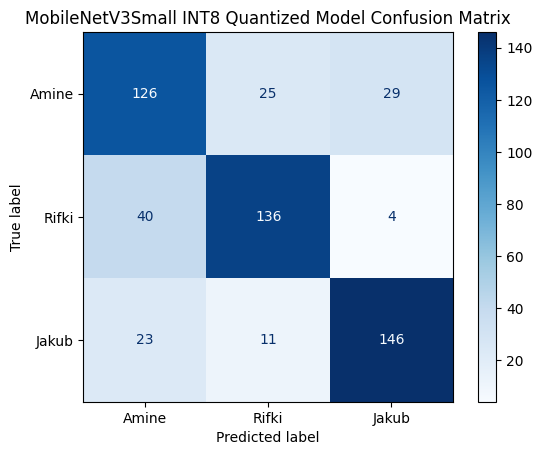

In [41]:
disp = ConfusionMatrixDisplay(confusion_matrix=quant_cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title('MobileNetV3Small INT8 Quantized Model Confusion Matrix')
plt.show()
